In [1]:
import specsuite as ss
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import glob
from astropy.table import QTable
from astropy.visualization import quantity_support
quantity_support();

from specutils import Spectrum
from astropy.nddata import StdDevUncertainty
from specutils import SpectralRegion
from specutils.manipulation import extract_region
from specutils.analysis import centroid, line_flux, fwhm
from specutils.fitting import estimate_line_parameters, fit_lines
from astropy.modeling import models
from specutils.fitting import find_lines_derivative


# hide some annoying warnings (comment out if you're having bugs!)
import warnings
warnings.catch_warnings()
warnings.simplefilter('ignore')

from IPython.display import Image, display

# allow interactive plots
# %matplotlib ipympl

In [2]:
# # Load into a DataFrame
# df = pd.read_csv('p_wavecal.csv')

# # Convert to a NumPy array
# p_wavecal = df.to_numpy()

# df = pd.read_csv('pdr_wavecal.csv')

# pdr_wavecal = df.to_numpy()

# df = pd.read_csv('paired_lines.csv')

# lines = df.to_numpy()

In [7]:
CAL_PATH = "UT260324/cals"
DATA_PATH = "UT260324/targets"
#DATA_REGION = (150, 825) #full image
DATA_REGION = (500, 800)
WAV_BOUNDS = (415 * u.nm, 705 * u.nm)

In [8]:
bias = ss.average_matching_files(
    path = CAL_PATH,
    tag = "bias",
    instrument = "KOSMOS",
    crop_bds = DATA_REGION,
)
raw_flat = ss.average_matching_files(
    path = CAL_PATH,
    tag = "internal-quartz-0.73-ctr-blue", 
    instrument="KOSMOS",
    crop_bds = DATA_REGION,
) - bias
raw_arc_neon = ss.average_matching_files(
    path = CAL_PATH,
    tag = "internal-neon-0.73-ctr-blue",
    instrument = "KOSMOS",
    crop_bds = DATA_REGION,
) - bias
raw_arc_krypton = ss.average_matching_files(
    path = CAL_PATH,
    tag = "internal-krypton-0.73-ctr-blue",
    instrument = "KOSMOS",
    crop_bds = DATA_REGION,
) - bias
raw_arc_argon = ss.average_matching_files(
    path = CAL_PATH,
    tag = "internal-argon-0.73-ctr-blue",
    instrument = "KOSMOS",
    crop_bds = DATA_REGION,
) - bias
raw_arc_helium = ss.average_matching_files(
    path = CAL_PATH,
    tag = "truss-helium-0.73-ctr-blue-0.73-ctr.0086",
    instrument = "KOSMOS",
    crop_bds = DATA_REGION,
) -bias
raw_darks = ss.average_matching_files(
    path = CAL_PATH,
    tag = "dark", 
    instrument="KOSMOS",
    crop_bds = DATA_REGION,
)

In [9]:
raw_science_M61 = ss.average_matching_files(
    path = DATA_PATH,
    tag = "M61_300s",
    instrument = "KOSMOS",
    crop_bds = DATA_REGION,
)
raw_science_NCG = ss.average_matching_files(
    path = DATA_PATH,
    tag = "NCG6946_300s",
    instrument = "KOSMOS",
    crop_bds = DATA_REGION,
)
raw_science_Feige34 = ss.collect_images_array(
    path = DATA_PATH,
    tag = "feige34",
    instrument = "KOSMOS",
    crop_bds = DATA_REGION,
)
raw_science_HR7596 = ss.collect_images_array(
    path = DATA_PATH,
    tag = "HR7596",
    instrument = "KOSMOS",
    crop_bds = DATA_REGION,
)

In [6]:
# ss.plot_image(
#     bias,
#     title = "KOSMOS Bias Exposure",
# )

# ss.plot_image(
#    raw_flat,
#    norm = 'log',
#    title = "KOSMOS Flatfield Exposure",
# )

In [23]:
arclamp = raw_arc_krypton
scienceM61 = raw_science_M61 - bias
scienceNCG = raw_science_NCG - bias
scienceFeige34 = raw_science_Feige34 - bias
scienceHR7596 = raw_science_HR7596 - bias

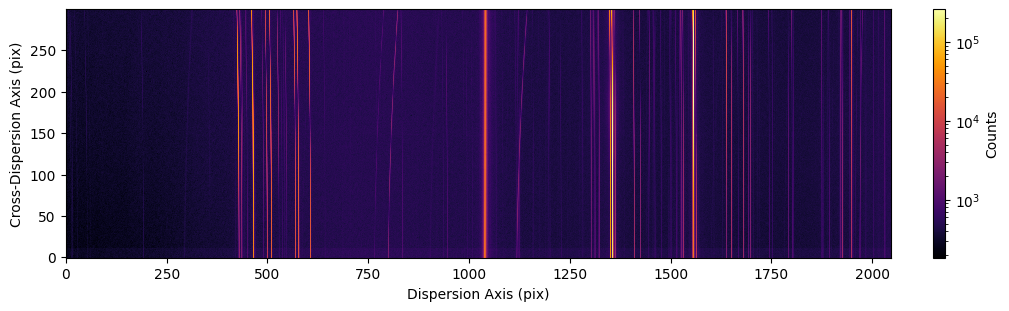

In [24]:
ss.plot_image(arclamp, norm="log")

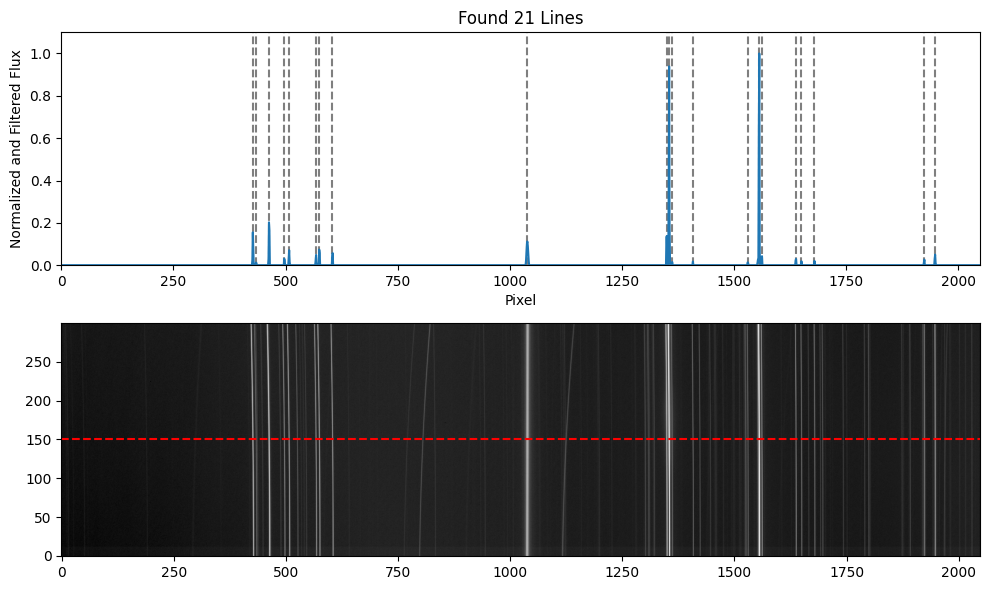

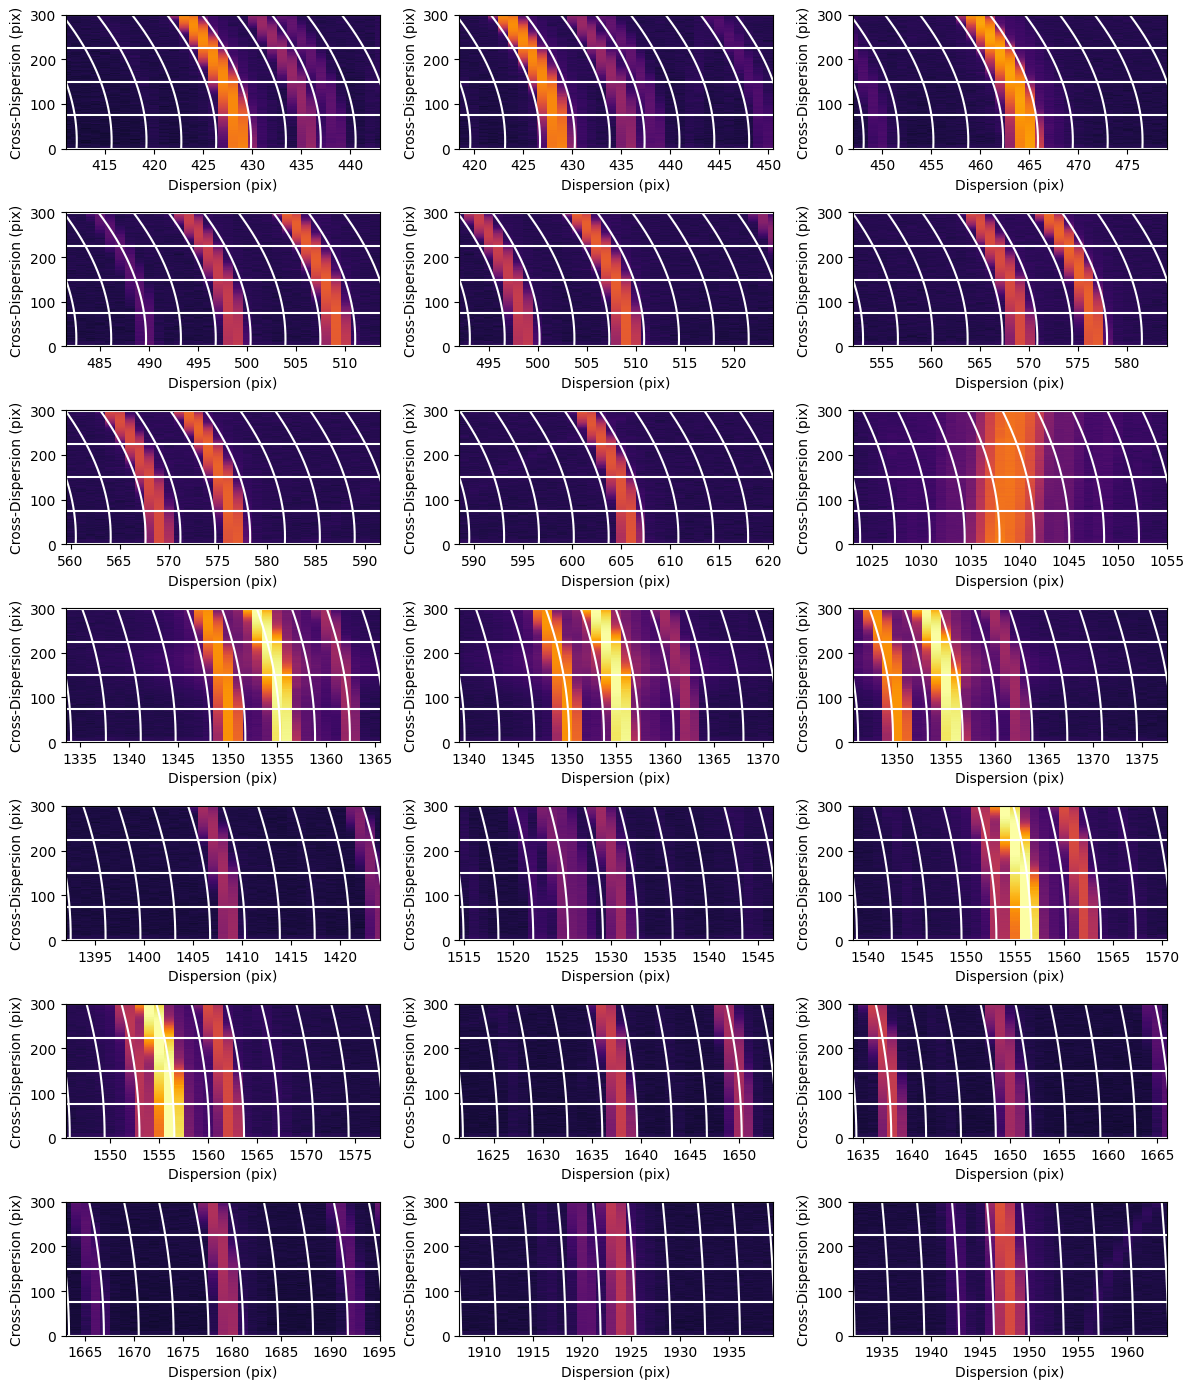

In [28]:
# Identifies the pixel positions of line emissions
locs, _ = ss.find_cal_lines(
    image = arclamp,
    std_variation = 30,
    debug = True,
)

# Models how line emissions are 'bent'
warp_model = ss.generate_warp_model(
    image = arclamp,
    guess = locs,
    #tolerance= 0.2,
    debug = True,
)

In [29]:
backgrounds_m61 = ss.extract_background(
    images = raw_science_M61,
    warp_model = warp_model,
    mask_region = (125, 240),
    #debug = True,
)
calibrated_scienceM61 = raw_science_M61 - backgrounds_m61[0]

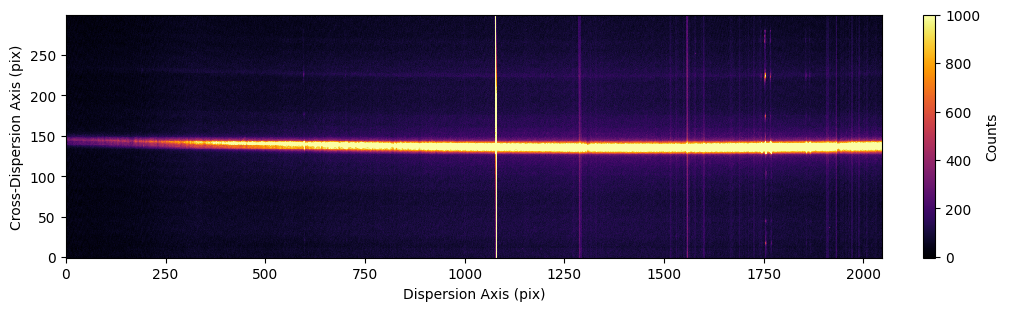

In [ ]:
ss.plot_image(scienceM61) #, vmax=1e3)

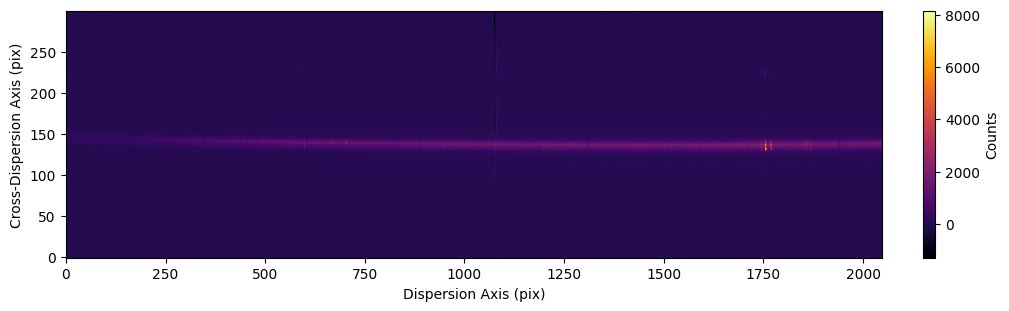

In [32]:
ss.plot_image(calibrated_scienceM61) #, vmax=1e3)

In [33]:
M61_flux = np.sum(calibrated_scienceM61, axis = 0)

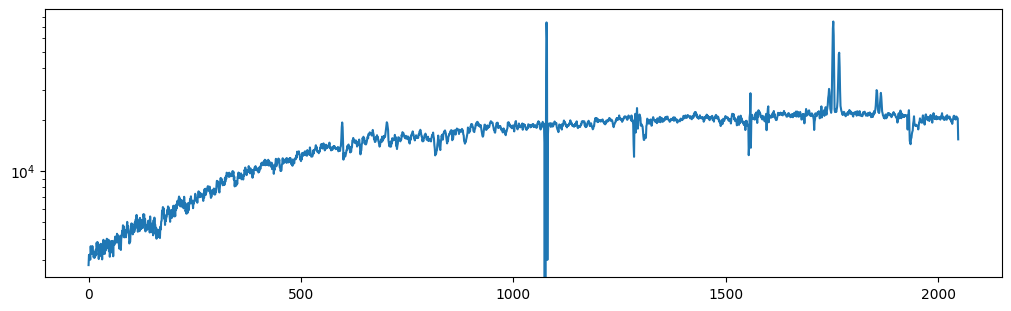

In [34]:
plt.plot(M61_flux)
plt.yscale("log")

In [35]:
# Re-runs background extraction and collects additional returns
returned_data_m61 = ss.extract_background(
    images = raw_science_M61,
    warp_model = warp_model,
    mask_region = (125,240),
    return_spectrum = True,
)

# Unpacks returned data into separate arrays
_m61, background_effpix_m61, background_flux_m61, effpix_map_m61 = returned_data_m61

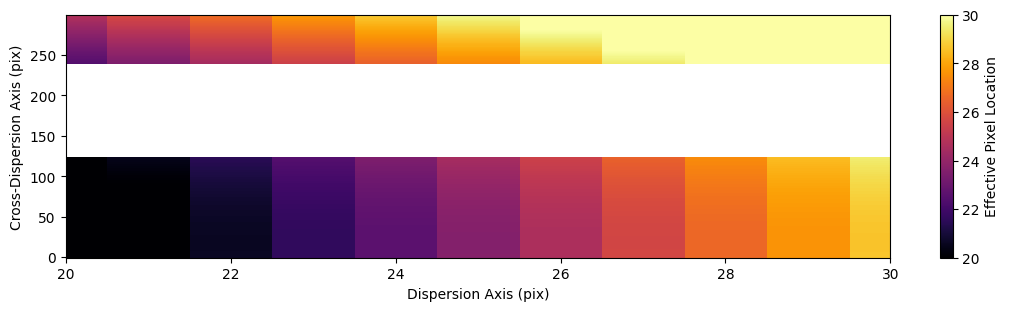

In [36]:
# Plots a small region of the effective pixel map
ss.plot_image(
    effpix_map_m61,
    cbar_label = "Effective Pixel Location",
    xlim = (20, 30),
    vmin = 20,
    vmax = 30,
)

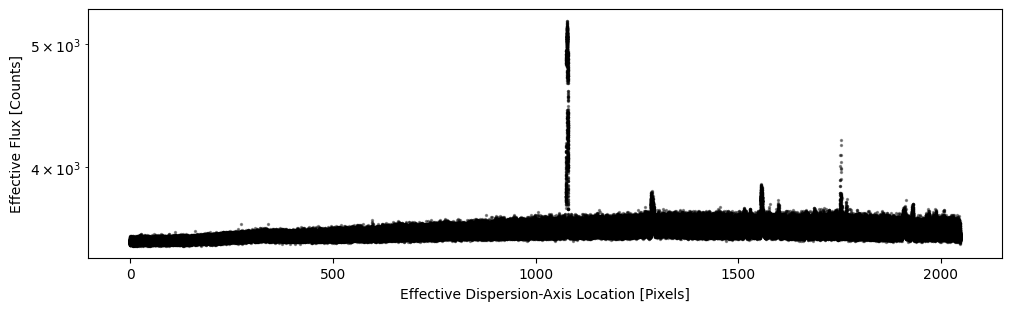

In [37]:
# Plots the supersampled background spectra
plt.scatter(
    returned_data_m61[1],
    returned_data_m61[2][0],
    color = "black",
    alpha = 0.4,
    s = 2,
)

# Formats the labels and scaling 
plt.xlabel("Effective Dispersion-Axis Location [Pixels]")
plt.ylabel("Effective Flux [Counts]")
plt.yscale("log")
plt.show()

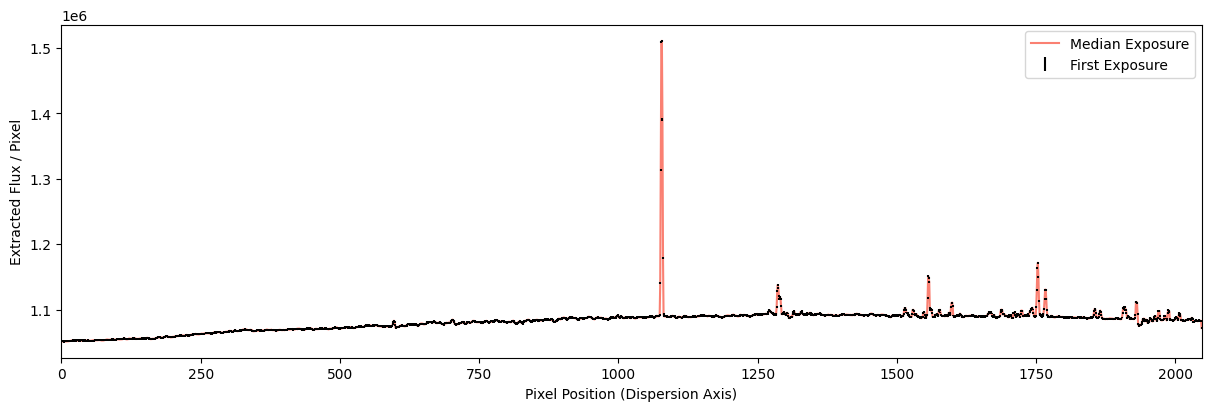

In [38]:
optimal_flux_m61, optimal_err_m61 = ss.horne_extraction(
    images = raw_science_M61,
    backgrounds = backgrounds_m61[0],
    profile = "moffat",
    RN = 6.0,
    debug = True,
)

In [39]:
backgrounds_NGC = ss.extract_background(
    images = raw_science_NCG,
    warp_model = warp_model,
    mask_region = (100, 220),
    #debug = True,
)
calibrated_scienceNCG = raw_science_NCG - backgrounds_NGC[0]

In [40]:
# Re-runs background extraction and collects additional returns
returned_data_NGC = ss.extract_background(
    images = raw_science_NCG,
    warp_model = warp_model,
    mask_region = (100,220),
    return_spectrum = True,
)

# Unpacks returned data into separate arrays
_NGC, background_effpix_NGC, background_flux_NGC, effpix_map_NGC = returned_data_NGC

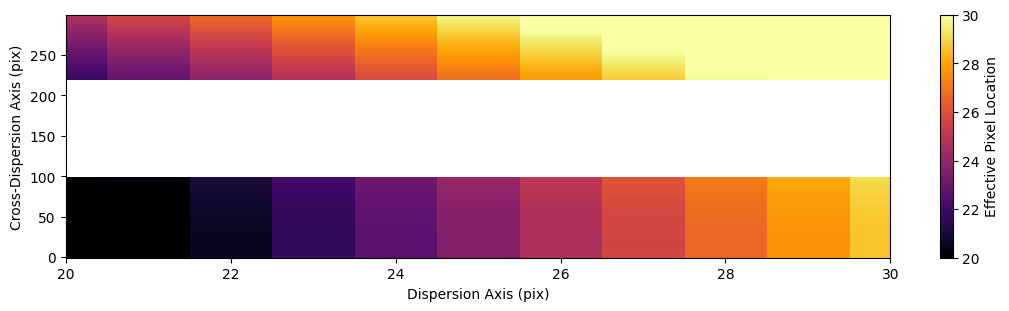

In [41]:
# Plots a small region of the effective pixel map
ss.plot_image(
    effpix_map_NGC,
    cbar_label = "Effective Pixel Location",
    xlim = (20, 30),
    vmin = 20,
    vmax = 30,
)

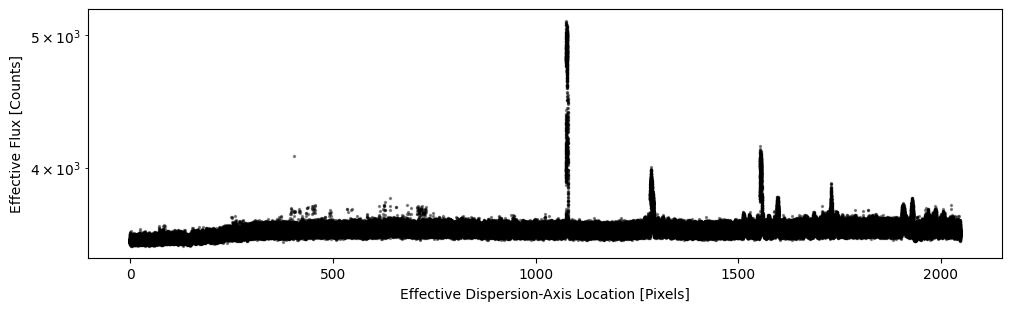

In [42]:
# Plots the supersampled background spectra
plt.scatter(
    returned_data_NGC[1],
    returned_data_NGC[2][0],
    color = "black",
    alpha = 0.4,
    s = 2,
)

# Formats the labels and scaling
plt.xlabel("Effective Dispersion-Axis Location [Pixels]")
plt.ylabel("Effective Flux [Counts]")
plt.yscale("log")
plt.show()

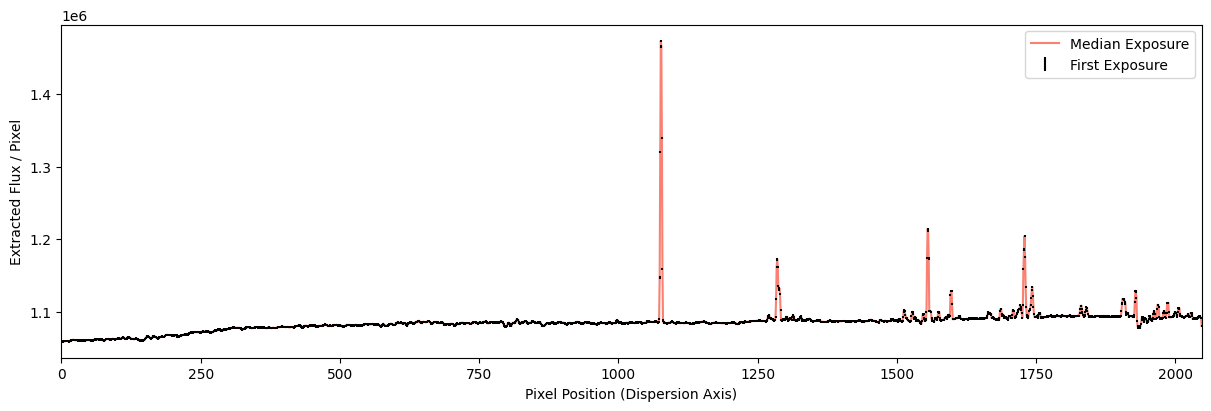

In [43]:
optimal_flux_NGC, optimal_err_NGC = ss.horne_extraction(
    images = raw_science_NCG,
    backgrounds = backgrounds_NGC[0], 
    profile = "moffat",
    RN = 6.0,
    debug = True,
)

In [49]:
arclamp_lines, _ = ss.find_cal_lines(arclamp, std_variation=30)

In [45]:
neon_lines = [
    4219.745,   # Ne II  intensity 150
    4233.850,   # Ne II  intensity 100
    4250.649,   # Ne II  intensity 120
    4369.862,   # Ne II  intensity 120
    4379.550,   # Ne II  intensity 150
    4385.059,   # Ne II  intensity 100
    4391.991,   # Ne II  intensity 200
    4397.990,   # Ne II  intensity 150
    4409.299,   # Ne II  intensity 150
    4413.215,   # Ne II  intensity 100
    4421.389,   # Ne II  intensity 100
    4428.516,   # Ne II  intensity 100
    4428.634,   # Ne II  intensity 100
    4430.904,   # Ne II  intensity 150
    4430.942,   # Ne II  intensity 150
    4457.049,   # Ne II  intensity 120
    4522.720,   # Ne II  intensity 100
    4537.7545,  # Ne I   intensity 100
    4569.057,   # Ne II  intensity 100
    4704.3949,  # Ne I   intensity 150
    4708.8594,  # Ne I   intensity 120
    4710.0650,  # Ne I   intensity 100
    4712.0633,  # Ne I   intensity 150
    4715.344,   # Ne I   intensity 150
    4788.9258,  # Ne I   intensity 100
    4827.338,   # Ne I   intensity 100
    4884.9170,  # Ne I   intensity 100
    5341.0938,  # Ne I   intensity 100
    5400.5618,  # Ne I   intensity 200
    5852.4879,  # Ne I   intensity 200
    5881.8952,  # Ne I   intensity 100
    6029.9969,  # Ne I   intensity 100
    6074.3377,  # Ne I   intensity 100
    6143.0626,  # Ne I   intensity 100
    6163.5939,  # Ne I   intensity 100
    6217.2812,  # Ne I   intensity 100
    6266.4950,  # Ne I   intensity 100
    6334.4278,  # Ne I   intensity 100
    6382.9917,  # Ne I   intensity 100
    6402.248,   # Ne I   intensity 200
    6506.5281,  # Ne I   intensity 150
    6598.9529,  # Ne I   intensity 100
    6929.4673,  # Ne I   intensity 1000
    7024.0504,  # Ne I   intensity 300
]  # 44 lines total

In [ ]:
# Krypton (Kr) emission lines between 4150 and 7050 Å
# Source: NIST Handbook of Basic Atomic Spectroscopic Data
# https://physics.nist.gov/PhysRefData/Handbook/Tables/kryptontable2_a.htm
# Wavelengths in Angstroms (air), sorted in ascending order

kr_lines = [
    4250.580,   # Kr II
    4273.9694,  # Kr I
    4282.9674,  # Kr I
    4292.923,   # Kr II
    4300.49,    # Kr II
    4317.81,    # Kr II
    4318.5513,  # Kr I
    4319.5794,  # Kr I
    4322.98,    # Kr II
    4351.3597,  # Kr I
    4355.477,   # Kr II  *** P (persistent) ***
    4362.6416,  # Kr I
    4369.69,    # Kr II
    4376.1216,  # Kr I
    4386.54,    # Kr II
    4399.9663,  # Kr I
    4425.1901,  # Kr I
    4431.685,   # Kr II
    4436.812,   # Kr II
    4453.9175,  # Kr I
    4463.6900,  # Kr I
    4475.014,   # Kr II
    4489.88,    # Kr II
    4502.3543,  # Kr I
    4523.14,    # Kr II
    4556.61,    # Kr II
    4577.209,   # Kr II
    4582.978,   # Kr II
    4592.80,    # Kr II
    4615.292,   # Kr II
    4619.166,   # Kr II  *** P ***
    4633.885,   # Kr II
    4658.876,   # Kr II  *** P ***
    4680.406,   # Kr II
    4691.301,   # Kr II
    4694.360,   # Kr II
    4739.002,   # Kr II  *** P ***
    4762.435,   # Kr II
    4765.744,   # Kr II  *** P ***
    4811.76,    # Kr II
    4825.18,    # Kr II
    4832.077,   # Kr II  *** P ***
    4846.612,   # Kr II  *** P ***
    4857.20,    # Kr II
    4945.59,    # Kr II
    5022.40,    # Kr II
    5086.52,    # Kr II
    5125.73,    # Kr II
    5208.32,    # Kr II
    5308.66,    # Kr II
    5333.41,    # Kr II
    5468.17,    # Kr II
    5562.2253,  # Kr I
    5570.2894,  # Kr I   *** P ***
    5580.3873,  # Kr I
    5649.5618,  # Kr I
    5681.89,    # Kr II
    5690.35,    # Kr II
    5832.8566,  # Kr I
    5870.9160,  # Kr I   *** P ***
    5992.22,    # Kr II
    5993.8502,  # Kr I
    6056.1263,  # Kr I
    6420.18,    # Kr II
    6421.0270,  # Kr I
    6456.2889,  # Kr I
    6570.07,    # Kr II
    6699.2296,  # Kr I
    6904.6788,  # Kr I
]

In [58]:
kr_lines = [
    # 6420.18,    # Kr II  intensity 100
    # 5992.22,    # Kr II  intensity 70
    # 5870.9160,  # Kr I   intensity 500 *** P ***
    # 5681.89,    # Kr II  intensity 130
    # 5570.2894,  # Kr I   intensity 300 *** P ***
    # 5333.41,    # Kr II  intensity 150
    # 5208.32,    # Kr II  intensity 150
    # 5125.73,    # Kr II  intensity 130 h
    # 4946.59,    # Kr II  intensity 100
    # 4846.612,   # Kr II  intensity 250 *** P ***
    # 4832.077,   # Kr II  intensity 250 *** P ***
    # 4765.744,   # Kr II  intensity 300 *** P ***
    # 4739.002,   # Kr II  intensity 1000 *** P ***
    # 4658.876,   # Kr II  intensity 700 *** P ***
    # 4633.885,   # Kr II  intensity 250
    # 4619.166,   # Kr II  intensity 300 *** P ***
    # 4577.209,   # Kr II  intensity 250
    # 4475.014,   # Kr II  intensity 250
    # 4463.6900,  # Kr I   intensity 130
    # 4436.812,   # Kr II  intensity 200
    # 4431.685,   # Kr II  intensity 150
    # 4376.1216,  # Kr I   intensity 130
    # 4355.477,   # Kr II  intensity 1000 *** P ***
    # 4319.5794,  # Kr I   intensity 150
    # 4317.81,    # Kr II  intensity 150 h
    # 4292.923,   # Kr II  intensity 200
    # 4273.9694,  # Kr I   intensity 150
]

In [59]:
kr_lines = [
    4250.580,   # Kr II
    4273.9694,  # Kr I
    4282.9674,  # Kr I
    4292.923,   # Kr II
    4300.49,    # Kr II
    4317.81,    # Kr II
    4318.5513,  # Kr I
    4319.5794,  # Kr I
    4322.98,    # Kr II
    4351.3597,  # Kr I
    4355.477,   # Kr II  *** P (persistent) ***
    4362.6416,  # Kr I
    4369.69,    # Kr II
    4376.1216,  # Kr I
    4386.54,    # Kr II
    4399.9663,  # Kr I
    4425.1901,  # Kr I
    4431.685,   # Kr II
    4436.812,   # Kr II
    4453.9175,  # Kr I
    4463.6900,  # Kr I
    4475.014,   # Kr II
    4489.88,    # Kr II
    4502.3543,  # Kr I
    4523.14,    # Kr II
    4556.61,    # Kr II
    4577.209,   # Kr II
    4582.978,   # Kr II
    4592.80,    # Kr II
    4615.292,   # Kr II
    4619.166,   # Kr II  *** P ***
    4633.885,   # Kr II
    4658.876,   # Kr II  *** P ***
    4680.406,   # Kr II
    4691.301,   # Kr II
    4694.360,   # Kr II
    4739.002,   # Kr II  *** P ***
    4762.435,   # Kr II
    4765.744,   # Kr II  *** P ***
    4811.76,    # Kr II
    4825.18,    # Kr II
    4832.077,   # Kr II  *** P ***
    4846.612,   # Kr II  *** P ***
    4857.20,    # Kr II
    4945.59,    # Kr II
    5022.40,    # Kr II
    5086.52,    # Kr II
    5125.73,    # Kr II
    5208.32,    # Kr II
    5308.66,    # Kr II
    5333.41,    # Kr II
    5468.17,    # Kr II
    5562.2253,  # Kr I
    5570.2894,  # Kr I   *** P ***
    5580.3873,  # Kr I
    5649.5618,  # Kr I
    5681.89,    # Kr II
    5690.35,    # Kr II
    5832.8566,  # Kr I
    5870.9160,  # Kr I   *** P ***
    5992.22,    # Kr II
    5993.8502,  # Kr I
    6056.1263,  # Kr I
    6420.18,    # Kr II
    6421.0270,  # Kr I
    6456.2889,  # Kr I
    6570.07,    # Kr II
    6699.2296,  # Kr I
    6904.6788,  # Kr I
]

In [47]:
# known_lines = [
#     5852.49, 5881.90, 5944.83, 6030.00, 6096.16, 6143.06, 6266.50, 6334.43, 6382.99, 6402.25,
#     6506.53, 6598.95, 6678.28, 6717.04, 6929.47, 6032.41, 7173.94, 7245.17, 7438.90, 7488.87,
#     8300.36, 8377.61, 8495.36, 8654.38, 8780.62, 8853.87,
# ]

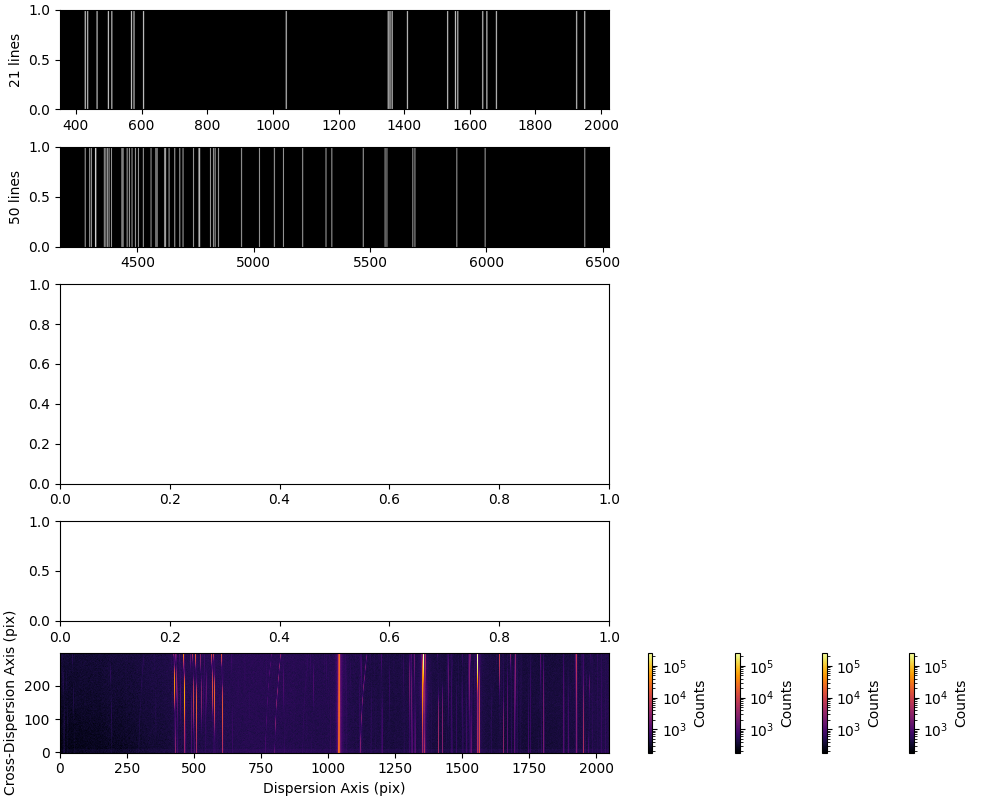

In [60]:
ss.plot_image(arclamp, norm="log")

WavecalWidget(children=(HBox(children=(Output(), VBox(children=(Button(description='Reset Upper Lines', style=…

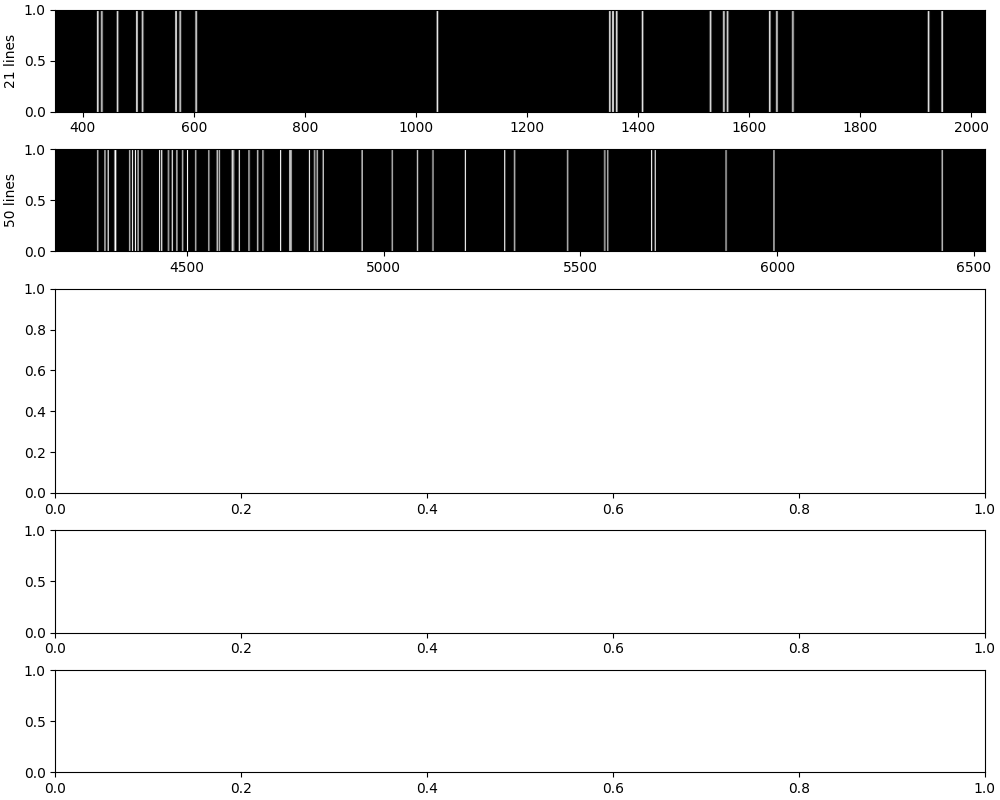

In [52]:
wavecal_widget = ss.WavecalWidget(
    upper_lines = arclamp_lines,
    lower_lines = kr_lines,
)

wavecal_widget.activate_widget()

In [29]:
paired_lines = wavecal_widget.final_lines # List of all paired lines
# p_wavecal = wavecal_widget.p # The final np.polynomial
# pdr_wavecal = wavecal_widget.pdr # The final derivative of np.polynomial

In [30]:
pixel = np.array(np.arange(2048))

In [31]:
df = pd.DataFrame(paired_lines)
df.to_csv('paired_lines.csv', index=False)

In [32]:
coeff = np.polyfit(paired_lines[1], paired_lines[0], deg=3)
p_wavecal = np.poly1d(coeff)

TypeError: 'NoneType' object is not subscriptable

In [ ]:
wavelengths = p_wavecal(pixel)

In [ ]:
wavelengths

In [ ]:
meta = ss.load_metadata(path = CAL_PATH, tag = "internal-neon")

In [ ]:
meta["DISPERSR"]

In [ ]:
# np.savetxt("p_wavecal.csv", p_wavecal, delimiter=",", fmt='%.2f', header="Col1,Col2,Col3", comments='')
# np.savetxt("pdr_wavecal.csv", p_wavecal, delimiter=",", fmt='%.2f', header="Col1,Col2,Col3", comments='')

In [ ]:
known_emission_lines = {
    "Hα":        6562.80,
    "[N II]":    6548.05,
    "[N II]":    6583.45,
    "[O II]":    7318.92,
    "[O II]":    7319.99,
    "[HB]": 4861,
    "[O III]": 4959, 
    "[O III]": 5007,
}

In [ ]:
flat_M61 = ss.flatfield_correction(scienceM61, raw_flat)

In [ ]:
print(np.shape(raw_science_NCG))

In [ ]:
#ss.plot_image(flat_M61)

In [ ]:
# import ASDtools as asdt
# lines = asdt.NIST_lines(["He I", "He II"], lower_wavelength=3000*u.AA, upper_wavelength=9000*u.AA)
# lines.df